In [1]:
# Import packages
import pandas as pd                 
import matplotlib.pyplot as plt     
import numpy as np                  
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
import seaborn as sns
import lightgbm as lgb
import shap
from sklearn.metrics import accuracy_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

shap.initjs()
pd.options.display.float_format = '{:,.2f}'.format

## 1. Data wrangling

Read the data from the source into a `pandas` data frame.

In [2]:
df_original = pd.read_csv("https://drive.google.com/uc?id=1_jYVXj7mt8Zzpjn8WGI111G-kWRTbfjU", index_col='date' , parse_dates=['date']) 
df_original.describe().T

,count,mean,std,min,25%,50%,75%,max
plant.feed.iron.comp,"241,920.00",56.28,5.19,42.74,52.61,56.02,59.72,65.78
plant.feed.silica.comp,"241,920.00",14.66,6.85,1.31,8.87,13.94,19.97,33.40
plant.flotation.sump01.starch.flow,"241,920.00","2,874.42","1,203.06",0.07,"2,081.50","3,021.68","3,727.12","6,295.13"
plant.flotation.sump01.amina.flow,"241,920.00",488.45,90.71,241.70,432.36,504.70,553.52,739.41
plant.flotation.sump01.discharge.flow,"241,920.00",397.54,9.60,376.27,394.89,399.32,402.63,418.63
plant.flotation.sump01.discharge.ph,"241,920.00",9.77,0.39,8.75,9.53,9.80,10.04,10.81
plant.flotation.sump01.discharge.density,"241,920.00",1.68,0.07,1.52,1.65,1.70,1.73,1.85
plant.flotation.bank01.column01.air.flow,"241,920.00",280.85,29.20,175.67,250.31,299.43,300.15,372.44
plant.flotation.bank01.column02.air.flow,"241,920.00",277.82,29.62,175.92,250.49,297.23,300.56,371.13
plant.flotation.bank01.column03.air.flow,"241,920.00",281.78,28.07,176.47,250.94,298.83,300.38,362.06


Rename the columns for clarity.

In [3]:
## Rename columns (variables) for easier interpretation
df_renamed = df_original.copy()

# Create cleaner variable names and units separately
variable_names = ['Feed Fe', 'Feed Si', 'Starch Flow', 'Amina Flow', 'Feed Flow', 'Feed pH', 'Feed Density'] + \
                ['Air Flow C1', 'Air Flow C2', 'Air Flow C3', 'Air Flow C4', 'Air Flow C5', 'Air Flow C6', 'Air Flow C7'] + \
                ['Level C1', 'Level C2', 'Level C3', 'Level C4', 'Level C5', 'Level C6', 'Level C7'] + \
                ['Product Fe', 'Product Si']

df_renamed.columns = variable_names
# Downsample to 15 minute intervals, taking the mean of each interval, and drop any remaining NaN values
df = df_renamed.resample('15min').mean().dropna()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Feed Fe,"16,128.00",56.28,5.19,42.74,52.61,56.02,59.72,65.78
Feed Si,"16,128.00",14.66,6.85,1.31,8.87,13.94,19.97,33.40
Starch Flow,"16,128.00","2,874.42","1,046.98",1.00,"2,122.55","2,919.32","3,619.80","6,287.17"
Amina Flow,"16,128.00",488.45,87.98,242.20,433.19,503.43,552.80,738.90
Feed Flow,"16,128.00",397.54,8.95,376.50,397.81,399.71,401.03,418.52
Feed pH,"16,128.00",9.77,0.39,8.75,9.53,9.80,10.04,10.81
Feed Density,"16,128.00",1.68,0.07,1.52,1.65,1.70,1.73,1.85
Air Flow C1,"16,128.00",280.85,29.14,175.80,250.15,299.76,299.99,356.43
Air Flow C2,"16,128.00",277.82,29.19,176.65,250.19,299.24,300.09,311.70
Air Flow C3,"16,128.00",281.78,28.01,176.61,250.15,299.79,299.98,334.56


## 2. Dimensionality reduction and clustering

Perform dimensionality reduction using PLS.

PLS (6 components)  |  R² = 0.1502  |  RMSE = 1.0291


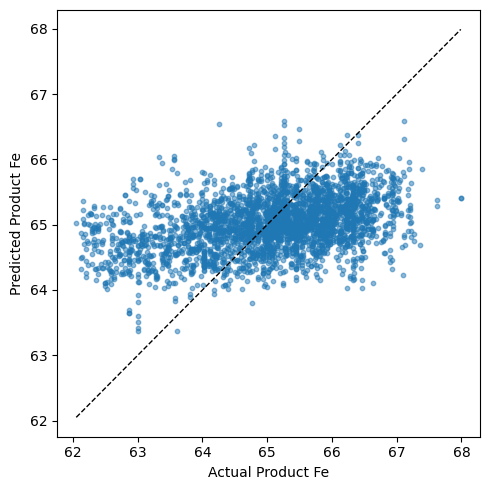

In [4]:
# --- Drop target and excluded features from df_full ---
df_model = df.drop(['Product Fe', 'Product Si', 'Feed Fe', 'Feed Si'], axis=1)

X = df_model.values
y = df['Product Fe'].values

# Standardise inputs (PLS is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# --- Fit PLS (choose n_components via cross-validation below) ---
n_components = 6
pls = PLSRegression(n_components=n_components)
pls.fit(X_train, y_train)

y_pred = pls.predict(X_test).ravel()
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"PLS ({n_components} components)  |  R² = {r2:.4f}  |  RMSE = {rmse:.4f}")

# --- Parity plot ---
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred, s=10, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('Actual Product Fe')
ax.set_ylabel('Predicted Product Fe')
plt.tight_layout()
plt.show()


# --- Project X into PLS latent space ---
T = pls.transform(X_scaled)

Perform clustering using k-means clustering.

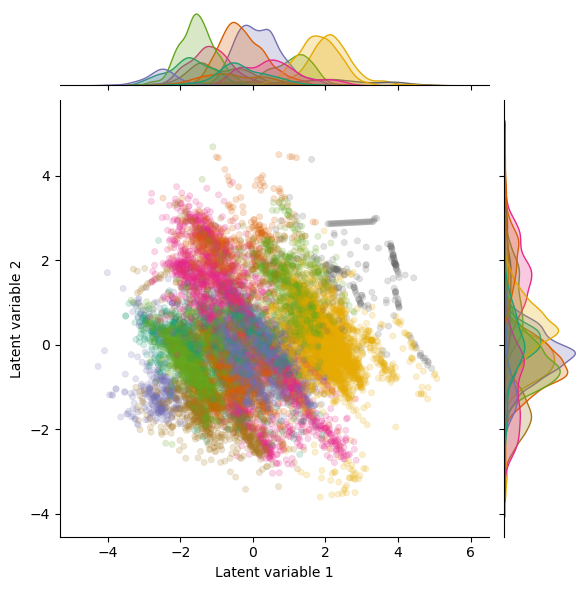

In [5]:
n_clusters = 15
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
pls_labels = kmeans.fit_predict(T)

plot_data = pd.DataFrame({'Latent variable 1': T[:, 0], 'Latent variable 2': T[:, 1], 'Cluster': pls_labels})
sns.jointplot(data=plot_data, x='Latent variable 1', y='Latent variable 2', hue='Cluster', palette='Dark2', 
              alpha=0.2, s=20, edgecolor=None, legend=False)
plt.show()

Plot each feature as a time series coloured according to cluster label.

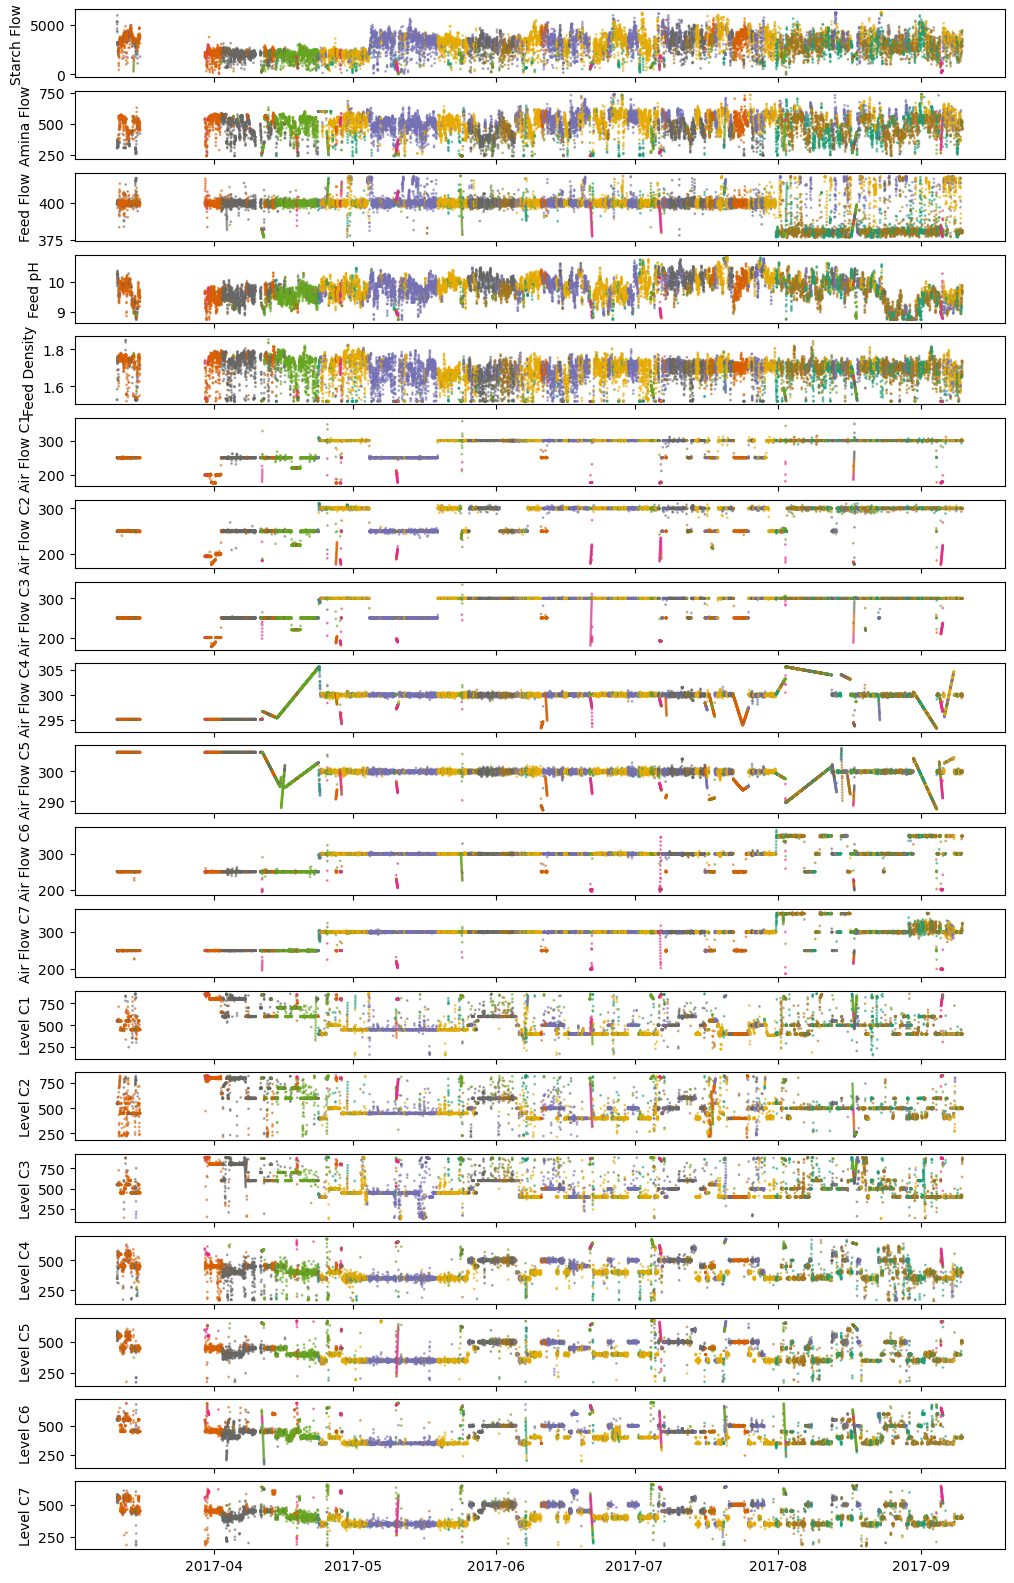

In [6]:
fig, ax = plt.subplots(19,1, figsize=(12, 20), sharex=True)
for (ax, col) in zip(ax.flatten(), df_model.columns):
    ax.scatter(df_model.index, df_model[col], c = pls_labels, s=1, cmap = 'Dark2', alpha = 0.5)
    ax.set_ylabel(col)   

Let's try to reduce the number of transitions by combining clusters together.

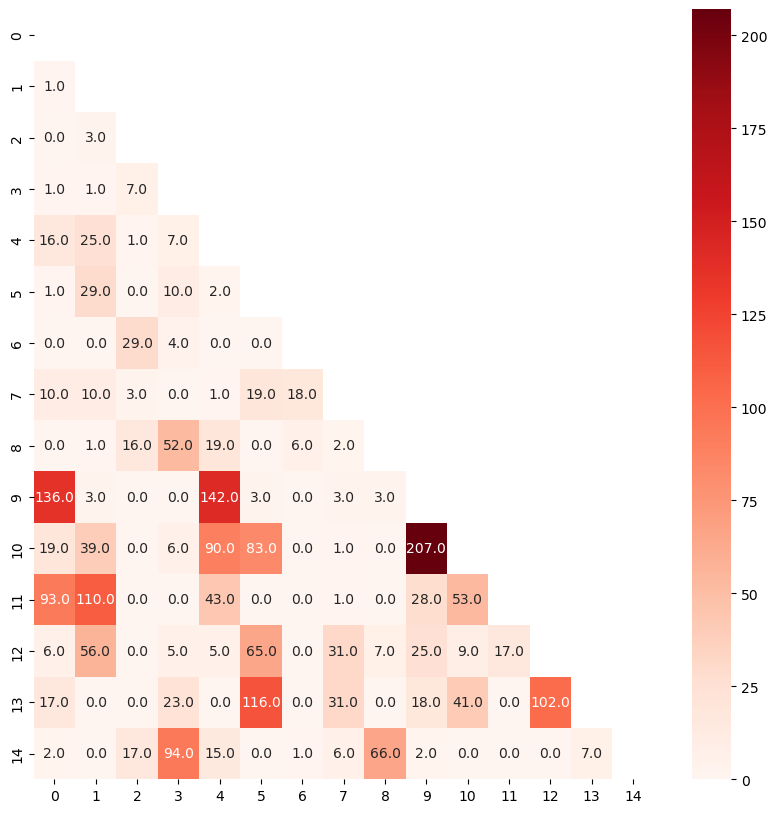

In [7]:
cluster_metric = pd.DataFrame({'Cluster t_{k}': pls_labels[:-1], 
                               'Cluster t_{k+1}': pls_labels[1:]})
cm = confusion_matrix(cluster_metric['Cluster t_{k}'], 
                      cluster_metric['Cluster t_{k+1}']) + 0.
cm += cm.T
cm[np.triu_indices_from(cm)] = np.nan

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='.1f', cmap='Reds')
plt.show()

Join clusters together where the transitions exceed a specific threshold (in this case, 100).

In [ ]:
join = [(0,4,6,7,9,10), (5,12,13), (1,11), (3,14), (2,), (8,)]
cluster_mapping = {}
for new_label, group in enumerate(join):
    for old_label in group:
        cluster_mapping[old_label] = new_label
pls_labels_joined = np.array([cluster_mapping.get(k) for k in pls_labels])

cluster_metric_joined = pd.DataFrame({'Cluster t_{k}': pls_labels_joined[:-1], 
                                      'Cluster t_{k+1}': pls_labels_joined[1:]})
cm = confusion_matrix(cluster_metric_joined['Cluster t_{k}'], 
                      cluster_metric_joined['Cluster t_{k+1}']) + 0.


plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='.1f', cmap='Reds')
plt.show()

C:\Users\tmlouw\AppData\Local\Temp\ipykernel_34744\1731624784.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['ordered_cluster_label'], y=df['Product Fe'], ax=ax, palette='Dark2')


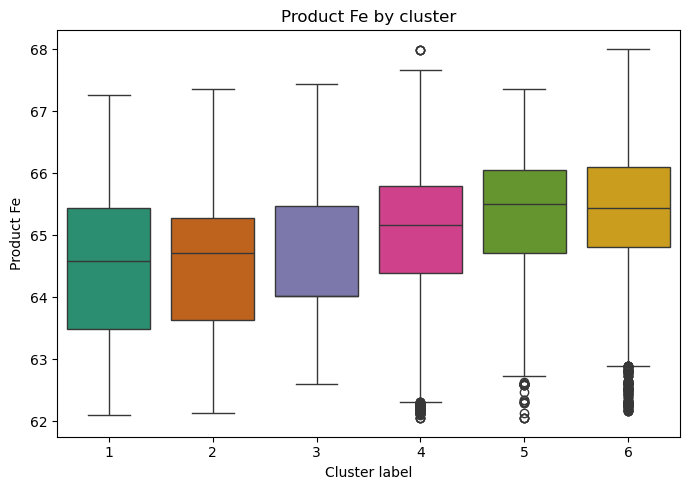

In [ ]:
# Compute mean Product Fe per cluster label
means = pd.Series(df['Product Fe']).groupby(pls_labels_joined).mean()
label_order_map = {label: i+1 for i, label in enumerate(means.sort_values().index.tolist())}
df['ordered_cluster_label'] = [label_order_map[l] for l in pls_labels_joined]

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(x=df['ordered_cluster_label'], y=df['Product Fe'], ax=ax, palette='Dark2')
ax.set_xlabel('Cluster label')
ax.set_ylabel('Product Fe')
ax.set_title('Product Fe by cluster')
plt.tight_layout()
plt.show()

# 3. Mode labelling
Perform SHAP analysis to describe individual modes

In [ ]:
# Train basic LightGBM classifier
lgb_classifier = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=-1  # Suppress warnings
)

y_pred = lgb_classifier.fit(df_model, df['ordered_cluster_label'])
y_pred = lgb_classifier.predict(df_model)
print(accuracy_score(pls_labels_joined, y_pred))

0.9997519841269841


In [53]:
# Initialize the SHAP explainer for the gradient boosting classifier
explainer = shap.TreeExplainer(lgb_classifier)
shap_values = explainer.shap_values(df_model)

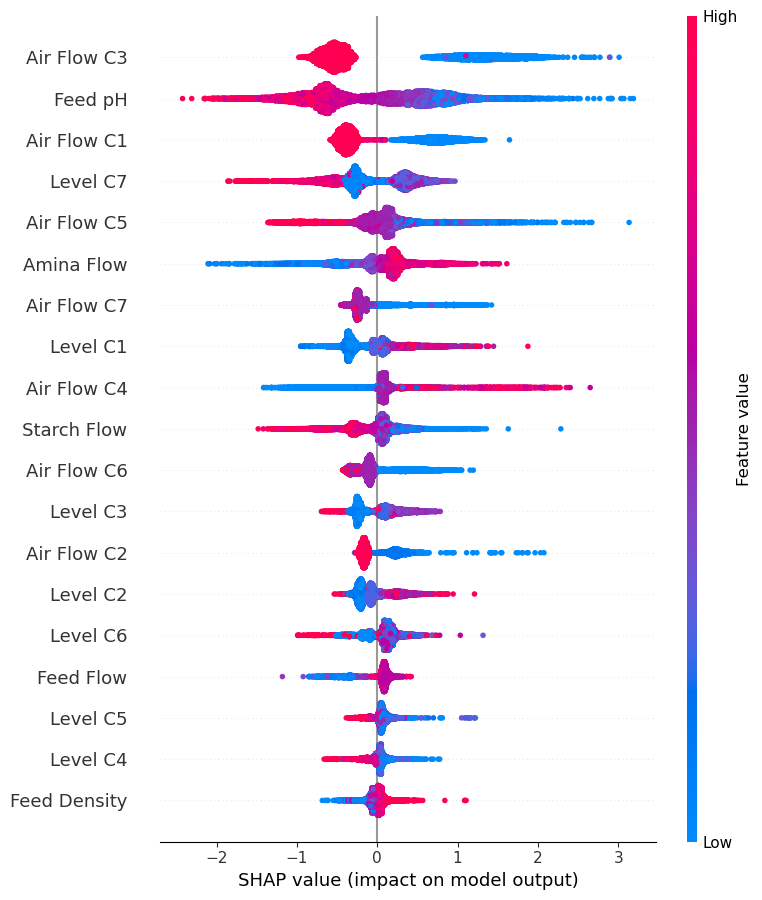

In [55]:
c = 5
shap.summary_plot(shap_values[:,:,c], df_model)

# 4. Transitions

Plot the inputs coloured according to clusters

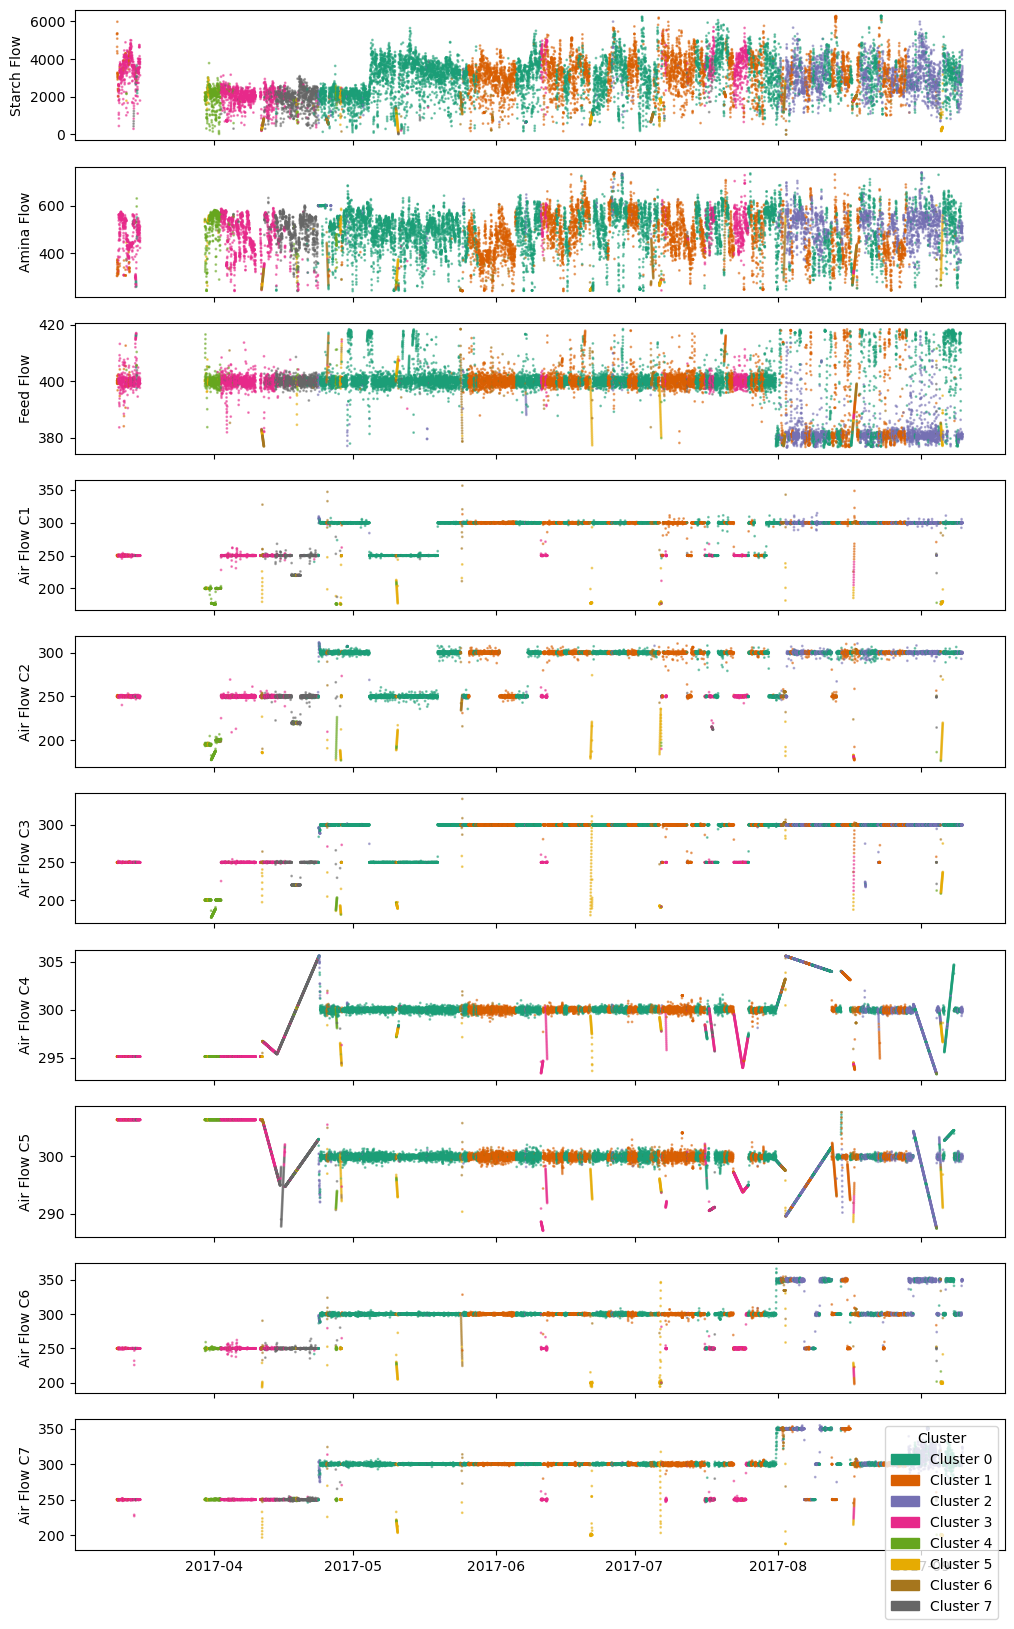

In [ ]:
inputs = ['Starch Flow', 'Amina Flow', 'Feed Flow',] + \
                ['Air Flow C1', 'Air Flow C2', 'Air Flow C3', 'Air Flow C4', 'Air Flow C5', 'Air Flow C6', 'Air Flow C7']
fig, ax = plt.subplots(10,1, figsize=(12, 20), sharex=True)
for (ax, col) in zip(ax.flatten(), inputs):
    scatter = ax.scatter(df.index, df[col], c=df['ordered_cluster_label'], s=1, cmap='Dark2', alpha=0.5)
    ax.set_ylabel(col)

# Add legend for cluster labels
import matplotlib.patches as mpatches
unique_labels = np.unique(df['ordered_cluster_label'])
legend_handles = [mpatches.Patch(color=scatter.cmap(scatter.norm(l)), label=f'Cluster {l}') for l in unique_labels]
ax.legend(handles=legend_handles, loc='upper right', title='Cluster')
